# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

For this project, I used the text of **Alice in Wonderland** as the training corpus. This dataset contains a large number of sentences, dialogues, and narrative descriptions, making it suitable for learning language structure and contextual relationships.

In [2]:
import requests

url = "https://www.gutenberg.org/files/11/11-0.txt"
corpus = requests.get(url).text

print("Total characters:", len(corpus))

Total characters: 144696


In [3]:
# clean the data

In [4]:
import re

corpus = corpus.lower()

corpus = re.sub(r'[^a-zA-Z\s]', '', corpus)

corpus = re.sub(r'\s+', ' ', corpus)

print(corpus[:500])

 start of the project gutenberg ebook illustration alices adventures in wonderland by lewis carroll the millennium fulcrum edition contents chapter i down the rabbithole chapter ii the pool of tears chapter iii a caucusrace and a long tale chapter iv the rabbit sends in a little bill chapter v advice from a caterpillar chapter vi pig and pepper chapter vii a mad teaparty chapter viii the queens croquetground chapter ix the mock turtles story chapter x the lobster quadrille chapter xi who stole t


# Methodology

The project haave more stages:

1. Text Collection and Preprocessing:

   * Loaded the text corpus.
   * Converted text to lowercase.
   * Removed special characters and extra spaces.

2. Tokenization:

   * Converted words into numerical tokens using Keras Tokenizer.
   * Created a vocabulary from the corpus.

3. Sequence Generation:

   * Generated input-output pairs where the model learns to predict the next word in a sequence.
   * Prepared training features (X) and target labels (y).

4. Model Development:

   * Implemented Vanilla RNN, LSTM, and GRU architectures.
   * Used embedding layers to represent words as dense vectors.
   * Increased embedding dimensions and hidden units for improved learning.

5. Training and Evaluation:

   * Trained all models for 200 epochs.
   * Compared model performance using training loss curves.
   * Generated sample text using the trained models.


# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [5]:
# Tokenization
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

# Convert corpus into tokens

tokens = tokenizer.texts_to_sequences([corpus])[0]

print("Total tokens:", len(tokens))

# Reduce Dataset Size (for Faster Training)

tokens = tokens[:10000]

print("Tokens Used:", len(tokens))

# create sequence
max_seq_len = 20

input_sequences = []

for i in range(max_seq_len, len(tokens)):
    seq = tokens[i-max_seq_len:i+1]
    input_sequences.append(seq)

print("Total Sequences:", len(input_sequences))

from tensorflow.keras.preprocessing.sequence import pad_sequences
input_sequences = np.array(input_sequences)

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

# sequence creation
# input_sequences = []
# for line in corpus.split('\n'):
#     token_list = tokenizer.texts_to_sequences([line])[0]
#     for i in range(1, len(token_list)):
#         n_gram_seq = token_list[:i+1]
#         input_sequences.append(n_gram_seq)

# max_len = max(len(seq) for seq in input_sequences)
# input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

# X = input_sequences[:, :-1]
# y = input_sequences[:, -1]

# print("X shape:", X.shape)
# print("y shape:", y.shape)

Vocabulary size: 2763
Total tokens: 26476
Tokens Used: 10000
Total Sequences: 9980
X shape: (9980, 20)
y shape: (9980,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [6]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=20),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])
rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    batch_size=128,
    verbose=1
)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.0412 - loss: 6.5443
Epoch 2/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0471 - loss: 6.0230
Epoch 3/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0473 - loss: 6.0778
Epoch 4/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0487 - loss: 5.9549
Epoch 5/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0479 - loss: 5.9512
Epoch 6/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0576 - loss: 5.9776
Epoch 7/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.0656 - loss: 5.8227
Epoch 8/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0745 - loss: 5.5962
Epoch 9/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0842 - loss: 5.4586
Epoch 10/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0939 - loss: 5.3179
Epoch 11/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1053 - loss: 5.1703
Epoch 12/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy

# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [7]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=20),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, batch_size=128, verbose=1)
print("LSTM training completed")

Epoch 1/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.0346 - loss: 6.6834
Epoch 2/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0462 - loss: 5.9914
Epoch 3/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0486 - loss: 5.8887
Epoch 4/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0496 - loss: 5.8168
Epoch 5/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.0534 - loss: 5.7508
Epoch 6/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.0597 - loss: 5.6862
Epoch 7/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0632 - loss: 5.6187
Epoch 8/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0693 - loss: 5.5507
Epoch 9/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0730 - loss: 5.4806
Epoch 10/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0796 - loss: 5.4135
Epoch 11/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0877 - loss: 5.3516
Epoch 12/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy

# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [8]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=20),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=1 , batch_size=128)
print("GRU training completed")

Epoch 1/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0447 - loss: 6.7397
Epoch 2/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0483 - loss: 6.0316
Epoch 3/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0505 - loss: 5.9270
Epoch 4/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0633 - loss: 5.7361
Epoch 5/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0790 - loss: 5.5434
Epoch 6/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0976 - loss: 5.3585
Epoch 7/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1173 - loss: 5.1851
Epoch 8/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.1300 - loss: 5.0238
Epoch 9/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1399 - loss: 4.8763
Epoch 10/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1462 - loss: 4.7377
Epoch 11/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1565 - loss: 4.6029
Epoch 12/200
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accurac

## 📉 Compare Training Loss

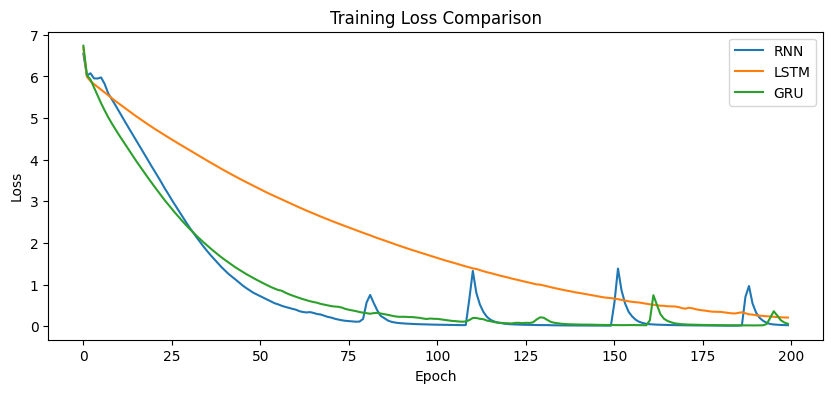

In [9]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [10]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=20, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [11]:
print("RNN :", generate_text(rnn_model, "deep learning", 15))
print("LSTM:", generate_text(lstm_model, "deep learning", 15))
print("GRU :", generate_text(gru_model, "deep learning", 15))

RNN : deep learning first if i thought it this is it said aloud and as how to a
LSTM: deep learning i shall have been changed for i cant understand it myself to begin with and
GRU : deep learning she remembered a little nervous about this for it might end you know said alice


# Conclusion

In this project, I implemented and compared three recurrent neural network architectures: Vanilla RNN, LSTM, and GRU for the task of text generation.

The models were trained on the **Alice in Wonderland corpus dataset** and successfully learned language patterns, grammar, and contextual relationships between words. The results demonstrated that while Vanilla RNN can learn simple sequential patterns, LSTM and GRU are more effective at handling long-term dependencies in text.

Among the tested models, GRU produced the most contextually meaningful text, while LSTM generated more grammatically coherent sentences.


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**